## Problem story: two products, two limited resources

A small food truck makes two products every morning:

- **Protein Shake** (decision variable $x$)  
- **Fruit Smoothie** (decision variable $y$)

Both $x$ and $y$ are *continuous* (think “batches”), so fractional values are allowed.

### Resources and limits

- **Protein powder (scoops)**: each shake uses 2 scoops, each smoothie uses 1 scoop, total available 10 scoops  
  $$
  2x + y \le 10
  $$
- **Fruit mix (cups)**: each shake uses 1 cup, each smoothie uses 2 cups, total available 12 cups  
  $$
  x + 2y \le 12
  $$
- **Demand caps**: at most 6 batches of each product  
  $$
  0 \le x \le 6,\quad 0 \le y \le 6
  $$

### Profit

- Profit per batch of shakes: 4 (e.g., €4)
- Profit per batch of smoothies: 5 (e.g., €5)

So the objective is:
$$
	\text{maximize } 4x + 5y
$$

---

## Mathematical LP (standard form for this notebook)

$$
\begin{aligned}
	\text{maximize }  & 4x + 5y \\
	\text{subject to } \ & 2x + y \le 10 \\
& x + 2y \le 12 \\
& 0 \le x \le 6 \\
& 0 \le y \le 6
\end{aligned}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.optimize import linprog

print("NumPy:", np.__version__)
import scipy
print("SciPy:", scipy.__version__)

NumPy: 2.4.2
SciPy: 1.17.0


## Helper code for geometry + plotting

The helper functions below:
- build the full set of inequalities (including bounds),
- compute the vertices of the feasible polygon (2D),
- draw the feasible region and constraint lines.

You do **not** need to modify these.

In [2]:
def _bounds_to_inequalities(bounds):
    # Convert bounds [(lb_x, ub_x), (lb_y, ub_y)] into additional inequalities A x <= b.
    A_extra, b_extra = [], []
    lines = []
    for j, (lb, ub) in enumerate(bounds):
        if lb is not None and not np.isneginf(lb):
            a = np.zeros(2)
            a[j] = -1.0
            A_extra.append(a)
            b_extra.append(-float(lb))
            lines.append((a, -float(lb)))
        if ub is not None and not np.isposinf(ub):
            a = np.zeros(2)
            a[j] = 1.0
            A_extra.append(a)
            b_extra.append(float(ub))
            lines.append((a, float(ub)))
    return np.array(A_extra, dtype=float), np.array(b_extra, dtype=float), lines


def feasible_vertices_2d(A_ub, b_ub, bounds, tol=1e-9):
    # Enumerate feasible vertices by intersecting pairs of constraint boundaries (2D only).
    A_ub = np.asarray(A_ub, dtype=float)
    b_ub = np.asarray(b_ub, dtype=float)

    # Build full inequality system including bounds
    A_bnd, b_bnd, bnd_lines = _bounds_to_inequalities(bounds)
    if A_bnd.size:
        A_full = np.vstack([A_ub, A_bnd])
        b_full = np.hstack([b_ub, b_bnd])
    else:
        A_full, b_full = A_ub.copy(), b_ub.copy()

    # Candidate boundary lines: each inequality boundary a^T x = b
    lines = [(A_ub[i], float(b_ub[i])) for i in range(A_ub.shape[0])] + bnd_lines

    verts = []
    for (a1, rhs1), (a2, rhs2) in combinations(lines, 2):
        M = np.vstack([a1, a2])
        det = np.linalg.det(M)
        if abs(det) < 1e-10:
            continue
        x = np.linalg.solve(M, np.array([rhs1, rhs2], dtype=float))

        if np.all(A_full @ x <= b_full + 1e-7):
            verts.append(x)

    # Deduplicate
    uniq = []
    for x in verts:
        if not any(np.linalg.norm(x - u) < 1e-6 for u in uniq):
            uniq.append(x)

    return np.array(uniq, dtype=float)


def convex_hull_order_2d(points):
    # Order vertices around the polygon by angle about the centroid.
    pts = np.asarray(points, dtype=float)
    c = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    order = np.argsort(angles)
    return pts[order]


def plot_feasible_region(A_ub, b_ub, bounds, ax=None, title=None, show_constraint_lines=True):
    # Plot the feasible region polygon and (optionally) the constraint boundary lines.
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    verts = feasible_vertices_2d(A_ub, b_ub, bounds)
    if len(verts) == 0:
        ax.set_title("No feasible vertices found (infeasible or unbounded?)")
        return ax, None

    hull = convex_hull_order_2d(verts)
    poly = np.vstack([hull, hull[0]])

    ax.fill(poly[:, 0], poly[:, 1], alpha=0.2)
    ax.plot(poly[:, 0], poly[:, 1], linewidth=2)
    ax.scatter(hull[:, 0], hull[:, 1], s=60)

    for k, v in enumerate(hull):
        ax.annotate(f"v{k}", (v[0], v[1]), textcoords="offset points", xytext=(6, 6))

    xs, ys = hull[:, 0], hull[:, 1]
    x_pad = 0.15 * max(1.0, xs.max() - xs.min())
    y_pad = 0.15 * max(1.0, ys.max() - ys.min())
    ax.set_xlim(xs.min() - x_pad, xs.max() + x_pad)
    ax.set_ylim(ys.min() - y_pad, ys.max() + y_pad)

    ax.set_xlabel("x (Protein shakes)")
    ax.set_ylabel("y (Fruit smoothies)")
    if title:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)

    if show_constraint_lines:
        xx = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 400)
        for i in range(len(b_ub)):
            a = np.asarray(A_ub[i], dtype=float)
            rhs = float(b_ub[i])
            if abs(a[1]) > 1e-12:
                yy = (rhs - a[0] * xx) / a[1]
                ax.plot(xx, yy, linestyle="--", linewidth=1)
            else:
                if abs(a[0]) > 1e-12:
                    x0 = rhs / a[0]
                    ax.axvline(x0, linestyle="--", linewidth=1)

    return ax, hull


def simplex_like_walk_on_polygon(vertices_ordered, c_min):
    # A simplex-like walk on a 2D convex polygon (adjacent vertices along the hull).
    V = np.asarray(vertices_ordered, dtype=float)
    c_min = np.asarray(c_min, dtype=float)

    start = int(np.argmin(np.sum(V**2, axis=1)))  # closest to origin
    path = [start]

    def obj(i):
        return float(c_min @ V[i])

    while True:
        i = path[-1]
        prev_i = (i - 1) % len(V)
        next_i = (i + 1) % len(V)

        best = i
        best_val = obj(i)
        for j in [prev_i, next_i]:
            val = obj(j)
            if val < best_val - 1e-10:
                best_val = val
                best = j

        if best == i:
            break
        path.append(best)

        if len(path) > len(V) + 2:
            break

    return path

## Step 1: Translate the LP into solver input

SciPy’s `linprog` expects inequalities of the form

$$
A_{\mathrm{ub}} \, x \le b_{\mathrm{ub}}
$$

and variable bounds `bounds=[(lb_x, ub_x), (lb_y, ub_y)]`.

We will solve the **minimization** form:

$$
	\text{minimize } \ -4x - 5y
$$

so the objective vector is

$$
c = \begin{bmatrix}-4 \ -5\end{bmatrix}.
$$

In [4]:
# Define class for LP problem
class FoodTruckLP:
    def __init__(self):
        # Objective for minimization: minimize -4x - 5y  (equivalent to maximizing 4x + 5y)
        # TODO: Replace None with the correct values
        self.c = np.array([-4, -5], dtype=float)

        # Constraints:
        # 2x + y <= 10
        # x + 2y <= 12
        # TODO: Replace None with the correct values
        self.A_ub = np.array([
            [2, 1],
            [1, 2]
        ], dtype=float)

        # TODO: Replace None with the correct values
        self.b_ub = np.array([10, 12], dtype=float)

        # Bounds: 0 <= x <= 6, 0 <= y <= 6
        # TODO: Replace None with the correct values
        self.bounds = [(0, 6), (0, 6)]

# Instantiate problem
lp_problem = FoodTruckLP()

c = lp_problem.c
A_ub = lp_problem.A_ub
b_ub = lp_problem.b_ub
bounds = lp_problem.bounds

## Step 2: Visualize the feasible region

Below we plot the feasible set


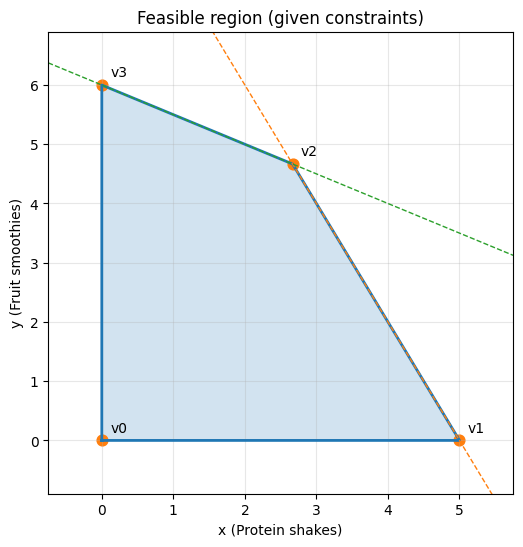

Vertices (in plotted order):
[[0.         0.        ]
 [5.         0.        ]
 [2.66666667 4.66666667]
 [0.         6.        ]]


In [5]:
# Human-readable constraints (for plotting only)
# 2x + y <= 10
# x + 2y <= 12
A_plot = A_ub
b_plot = b_ub

# Demand caps as bounds: 0 <= x <= 6, 0 <= y <= 6
bounds_plot = bounds
fig, ax = plt.subplots(figsize=(6, 6))
ax, hull = plot_feasible_region(A_plot, b_plot, bounds_plot, ax=ax, title="Feasible region (given constraints)")
plt.show()

print("Vertices (in plotted order):")
print(hull)

## Step 3: Solve with `linprog`

Once you define the arrays, run the cell below to solve and print the optimal solution.

In [6]:
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

print("Status:", res.message)
print("Optimal (x, y) =", res.x)
print("Maximum profit =", -(res.fun))

Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal (x, y) = [2.66666667 4.66666667]
Maximum profit = 34.0


## Step 4: Visualize the solution and a simplex-like walk across vertices

The plot below:
- redraws the feasible region from your `A_ub, b_ub, bounds`,
- shows the optimal point from `linprog`,
- shows a simplex-like walk across adjacent vertices of the feasible polygon.

Note: real industrial solvers can follow different pivoting rules (so their exact sequence of visited vertices may differ),
but the walk shown here is a faithful “move along edges to improve the objective” picture of what simplex-style methods do.

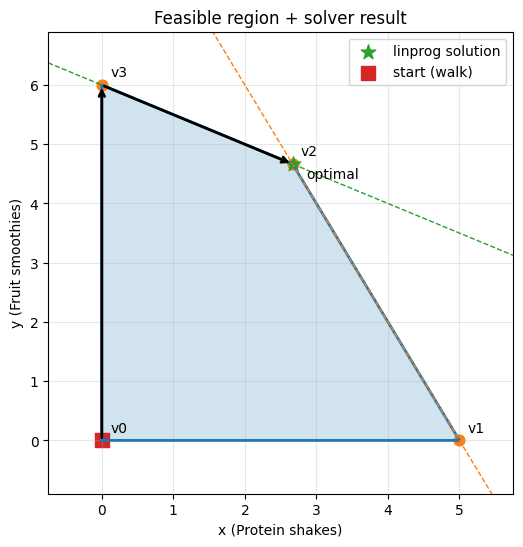

Walk visited vertices (in order):
  (0, 0)   profit=-0
  (0, 6)   profit=30
  (2.667, 4.667)   profit=34


In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax, hull = plot_feasible_region(A_ub, b_ub, bounds, ax=ax, title="Feasible region + solver result", show_constraint_lines=True)

# Mark solver solution
x_opt, y_opt = res.x
ax.scatter([x_opt], [y_opt], s=120, marker="*", label="linprog solution")
ax.annotate("optimal", (x_opt, y_opt), textcoords="offset points", xytext=(10, -10))

# Simplex-like walk (minimization objective c^T x)
path_idx = simplex_like_walk_on_polygon(hull, c_min=c)

for t in range(len(path_idx) - 1):
    p = hull[path_idx[t]]
    q = hull[path_idx[t + 1]]
    ax.annotate(
        "",
        xy=(q[0], q[1]),
        xytext=(p[0], p[1]),
        arrowprops=dict(arrowstyle="->", linewidth=2),
    )

start_v = hull[path_idx[0]]
ax.scatter([start_v[0]], [start_v[1]], s=90, marker="s", label="start (walk)")
ax.legend(loc="best")
plt.show()

print("Walk visited vertices (in order):")
for i in path_idx:
    v = hull[i]
    print(f"  ({v[0]:.4g}, {v[1]:.4g})   profit={-(c @ v):.4g}")